In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_blobs
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_error

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [56]:
ASOSdata = pd.read_csv('/content/drive/MyDrive/weather_data.csv', encoding='cp949')

In [57]:
ASOSdata.info()

# 시간 데이터 분리
ASOSdata['date'] = pd.to_datetime(ASOSdata['date'])

ASOSdata['month'] = ASOSdata['date'].dt.month #월
ASOSdata['day'] = ASOSdata['date'].dt.day #일
ASOSdata['hour'] = ASOSdata['date'].dt.hour #시

# 필요하지 않은 데이터 제거 (장소, 장소명, 분리전 시간)
ASOSdata = ASOSdata.drop('place', axis=1)
ASOSdata = ASOSdata.drop('place_name', axis=1)
ASOSdata = ASOSdata.drop('date', axis=1)

# NaN 데이터 '0' 처리
ASOSdata = ASOSdata.fillna(0)

ASOSdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34966 entries, 0 to 34965
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   place       34966 non-null  int64  
 1   place_name  34966 non-null  object 
 2   date        34966 non-null  object 
 3   temp        34966 non-null  float64
 4   prec        3928 non-null   float64
 5   wind_speed  34966 non-null  float64
 6   wind_dir    34966 non-null  int64  
 7   humi        34964 non-null  float64
 8   dew_point   34964 non-null  float64
 9   pressure    34965 non-null  float64
 10  pressure2   34965 non-null  float64
 11  sunlight    19121 non-null  float64
 12  sunlight2   19118 non-null  float64
 13  VD          34966 non-null  int64  
 14  weather     11394 non-null  float64
 15  G_temp      34963 non-null  float64
dtypes: float64(11), int64(3), object(2)
memory usage: 4.3+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34966 entries, 0 to 34965
Data columns (

In [58]:
ASOSdata.describe(include='all')

,temp,prec,wind_speed,wind_dir,humi,dew_point,pressure,pressure2,sunlight,sunlight2,VD,weather,G_temp,month,day,hour
count,34966.000000,34966.000000,34966.000000,34966.000000,34966.000000,34966.000000,34966.000000,34966.000000,34966.000000,34966.000000,34966.000000,3.496600e+04,34966.000000,34966.000000,34966.000000,34966.000000
mean,14.350578,0.154433,1.396325,175.583138,61.338071,6.237399,1009.496948,1016.469496,0.268309,0.618944,2342.215981,4.940593e+03,16.556824,6.508923,15.691043,11.500029
std,10.663971,1.183136,0.960794,114.375912,19.112554,11.631799,9.994192,10.261117,0.409437,0.929904,1510.942033,3.514836e+05,12.859131,3.441467,8.775858,6.922416
min,-16.700000,0.000000,0.000000,0.000000,0.000000,-27.300000,0.000000,0.000000,0.000000,0.000000,5.000000,0.000000e+00,-8.400000,1.000000,1.000000,0.000000
25%,5.800000,0.000000,0.700000,50.000000,47.000000,-3.100000,1003.000000,1009.700000,0.000000,0.000000,1100.000000,0.000000e+00,5.500000,4.000000,8.000000,5.250000
50%,15.400000,0.000000,1.200000,200.000000,63.000000,6.200000,1009.700000,1016.700000,0.000000,0.010000,2034.000000,0.000000e+00,17.100000,7.000000,16.000000,11.500000
75%,23.400000,0.000000,2.000000,270.000000,77.000000,16.900000,1016.000000,1023.200000,0.600000,1.050000,3474.000000,1.900000e+01,25.600000,9.000000,23.000000,17.750000
max,36.000000,42.700000,7.300000,360.000000,97.000000,26.300000,1032.000000,1039.900000,1.000000,3.920000,6000.000000,4.019020e+07,62.200000,12.000000,31.000000,23.000000


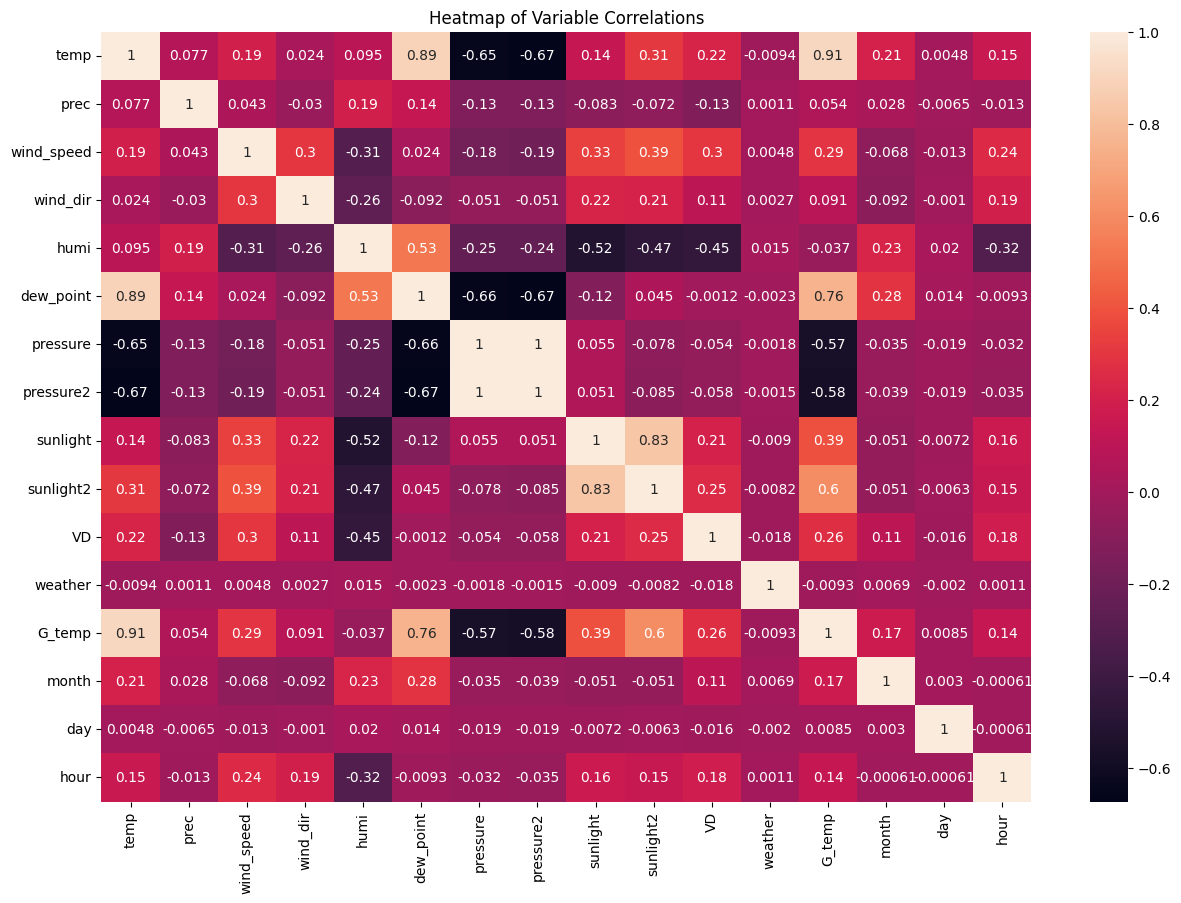

In [60]:
plt.figure(figsize=(15,10))
sns.heatmap(ASOSdata.corr(),annot=True)
plt.title('Heatmap of Variable Correlations')
plt.show()

In [68]:
# 독립 변수와 종속 변수 선택
features = ["temp", "wind_speed", "humi", "sunlight", "sunlight2", "G_temp", "hour"]
target = "VD"

# 결측치 제거
data_clean = ASOSdata.dropna(subset=features + [target])
X = data_clean[features]
y = data_clean[target]

# 데이터 분할 (학습용 80%, 테스트용 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

# 다항 특징 생성 (다항식 사용)
poly = PolynomialFeatures(degree=1)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# 다항 회귀 모델 학습
model = LinearRegression()
model.fit(X_train_poly, y_train)

# 성능 평가
y_pred = model.predict(X_test_poly)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

#print("=== 5차 다항 회귀 ===")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"R^2 Score: {r2}")

Mean Squared Error (MSE): 1612096.2176060332
Mean Absolute Error (MAE): 1037.7699064297426
R^2 Score: 0.31009889839826177


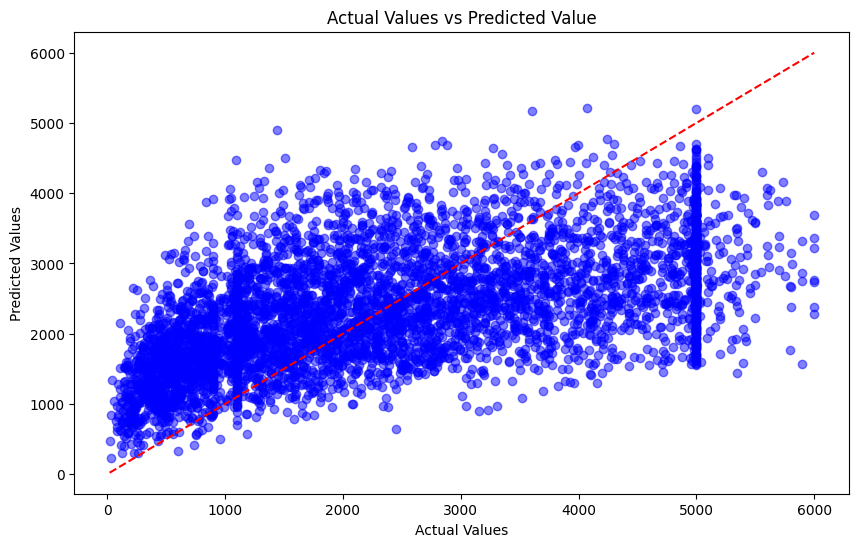

In [69]:
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual Values vs Predicted Value')
plt.show()